# ML Engineer 1 — Supervised Learning
## Prediksi Kebutuhan Maintenance Mesin

**Dataset:** Smart Manufacturing Data  
**Target:** `maintenance_required`  
**Model utama:** Random Forest Classifier

### Tujuan
Membangun model supervised learning untuk memprediksi apakah sebuah mesin membutuhkan maintenance berdasarkan kondisi sensor dan informasi operasional yang tersedia.

Alur notebook:

1. Import library
2. Load dataset
3. Memahami struktur data
4. Data quality check
5. Exploratory Data Analysis (EDA)
6. Analisis target
7. Analisis potensi data leakage
8. Menentukan fitur untuk model
9. Train-test split
10. Baseline model
11. Random Forest
12. Evaluasi
13. Confusion matrix
14. Feature importance
15. Contoh prediksi
16. Menyimpan model

In [1]:
# 1. IMPORT LIBRARIES

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries berhasil di-import.")

Libraries berhasil di-import.


## 2. Load Dataset

Jika notebook dijalankan di komputer lokal, ubah `DATA_PATH` sesuai lokasi CSV.

Jika menggunakan Google Colab, upload CSV terlebih dahulu lalu sesuaikan path.

In [2]:
DATA_PATH = r"/mnt/data/smart_manufacturing_data_10000(1).csv"

df = pd.read_csv(DATA_PATH)

print("Dataset berhasil dimuat.")
print("Shape:", df.shape)
df.head()

Dataset berhasil dimuat.
Shape: (10000, 13)


,timestamp,machine_id,temperature,vibration,humidity,pressure,energy_consumption,machine_status,anomaly_flag,predicted_remaining_life,failure_type,downtime_risk,maintenance_required
0,2025-01-09 14:06:00,45,76.36,46.28,70.25,3.13,1.75,1,0,365,Normal,0.0,0
1,2025-02-09 08:55:00,29,94.44,43.91,32.95,4.23,4.50,1,1,28,Normal,1.0,1
2,2025-01-13 09:56:00,10,66.98,64.04,63.52,2.78,2.75,0,0,499,Normal,0.0,0
3,2025-03-03 19:08:00,7,76.19,66.79,45.49,4.25,3.93,2,0,260,Normal,0.0,1
4,2025-02-24 21:54:00,46,78.14,66.23,59.70,1.69,1.62,1,0,32,Normal,0.0,0


In [3]:
# Informasi struktur dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   timestamp                 10000 non-null  object 
 1   machine_id                10000 non-null  int64  
 2   temperature               10000 non-null  float64
 3   vibration                 10000 non-null  float64
 4   humidity                  10000 non-null  float64
 5   pressure                  10000 non-null  float64
 6   energy_consumption        10000 non-null  float64
 7   machine_status            10000 non-null  int64  
 8   anomaly_flag              10000 non-null  int64  
 9   predicted_remaining_life  10000 non-null  int64  
 10  failure_type              10000 non-null  object 
 11  downtime_risk             10000 non-null  float64
 12  maintenance_required      10000 non-null  int64  
dtypes: float64(6), int64(5), object(2)
memory usage: 1015.8+ KB


In [4]:
# Statistik deskriptif
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,10000,10000,2025-01-09 14:06:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
machine_id,10000.0,NaN,NaN,NaN,25.6339,14.413551,1.0,13.0,26.0,38.0,50.0
temperature,10000.0,NaN,NaN,NaN,74.998667,9.991096,39.85,68.25,75.14,81.75,114.21
vibration,10000.0,NaN,NaN,NaN,50.151906,14.871322,-15.83,40.14,50.2,60.22,106.61
humidity,10000.0,NaN,NaN,NaN,55.136088,14.42175,30.0,42.675,55.235,67.56,79.99
pressure,10000.0,NaN,NaN,NaN,2.991506,1.1508,1.0,1.98,3.0,3.99,5.0
energy_consumption,10000.0,NaN,NaN,NaN,2.745488,1.299822,0.5,1.62,2.72,3.89,5.0
machine_status,10000.0,NaN,NaN,NaN,1.0021,0.446224,0.0,1.0,1.0,1.0,2.0
anomaly_flag,10000.0,NaN,NaN,NaN,0.0876,0.282726,0.0,0.0,0.0,0.0,1.0
predicted_remaining_life,10000.0,NaN,NaN,NaN,234.1675,150.711156,1.0,94.0,231.0,365.0,499.0


## 3. Data Quality Check

Kita memeriksa:

- missing values
- duplicate rows
- tipe data
- jumlah nilai unik setiap kolom

In [5]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
print("Missing values:")
display(missing.to_frame("missing_count"))

Missing values:


,missing_count
timestamp,0
machine_id,0
temperature,0
vibration,0
humidity,0
pressure,0
energy_consumption,0
machine_status,0
anomaly_flag,0
predicted_remaining_life,0


In [6]:
# Duplicate rows
duplicate_count = df.duplicated().sum()
print("Jumlah duplicate rows:", duplicate_count)

Jumlah duplicate rows: 0


In [7]:
# Data type dan unique values
quality_table = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "unique_values": df.nunique(),
    "missing_values": df.isnull().sum()
})

quality_table

,dtype,unique_values,missing_values
timestamp,object,10000,0
machine_id,int64,50,0
temperature,float64,3723,0
vibration,float64,4741,0
humidity,float64,4282,0
pressure,float64,401,0
energy_consumption,float64,451,0
machine_status,int64,3,0
anomaly_flag,int64,2,0
predicted_remaining_life,int64,499,0


## 4. Memahami Target

Target yang digunakan adalah:

`maintenance_required`

- `0` = maintenance tidak diperlukan
- `1` = maintenance diperlukan

Kita cek distribusi target karena model klasifikasi sebaiknya tidak dievaluasi menggunakan accuracy saja.

In [8]:
target = "maintenance_required"

target_counts = df[target].value_counts().sort_index()
target_percent = df[target].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percent.round(2)
})

target_summary

,count,percentage
maintenance_required,,
0,8016,80.16
1,1984,19.84


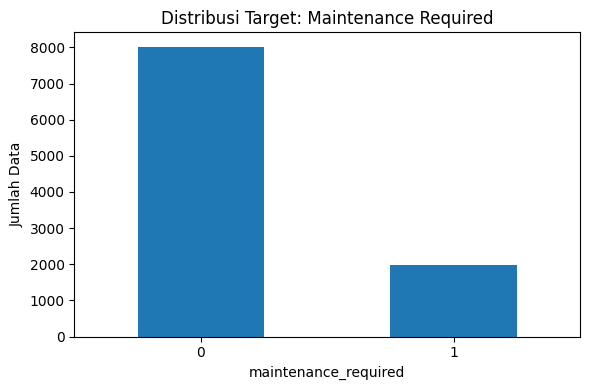

In [9]:
plt.figure(figsize=(6, 4))
target_counts.plot(kind="bar")
plt.title("Distribusi Target: Maintenance Required")
plt.xlabel("maintenance_required")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Exploratory Data Analysis

Kita melihat distribusi fitur sensor utama dan hubungan awalnya dengan target.

In [10]:
numeric_features = [
    "temperature",
    "vibration",
    "humidity",
    "pressure",
    "energy_consumption",
    "predicted_remaining_life"
]

df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature,10000.0,74.998667,9.991096,39.85,68.250,75.140,81.75,114.21
vibration,10000.0,50.151906,14.871322,-15.83,40.140,50.200,60.22,106.61
humidity,10000.0,55.136088,14.421750,30.00,42.675,55.235,67.56,79.99
pressure,10000.0,2.991506,1.150800,1.00,1.980,3.000,3.99,5.00
energy_consumption,10000.0,2.745488,1.299822,0.50,1.620,2.720,3.89,5.00
predicted_remaining_life,10000.0,234.167500,150.711156,1.00,94.000,231.000,365.00,499.00


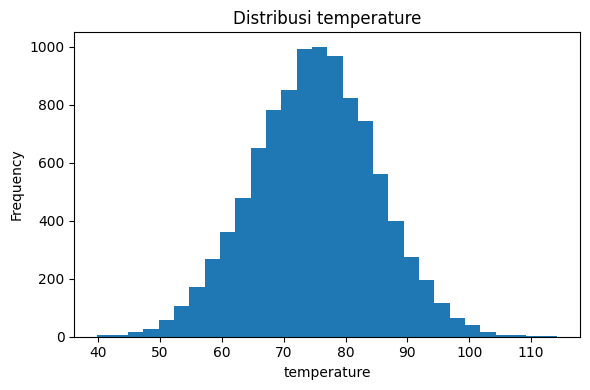

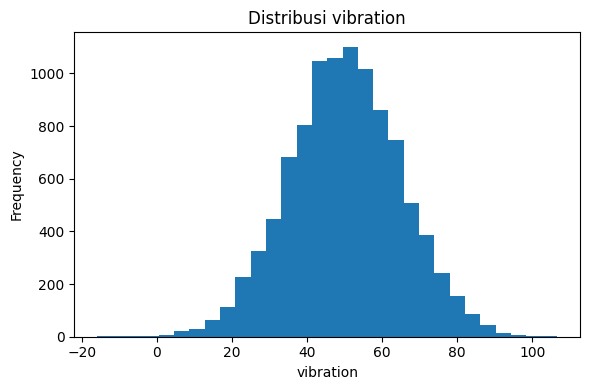

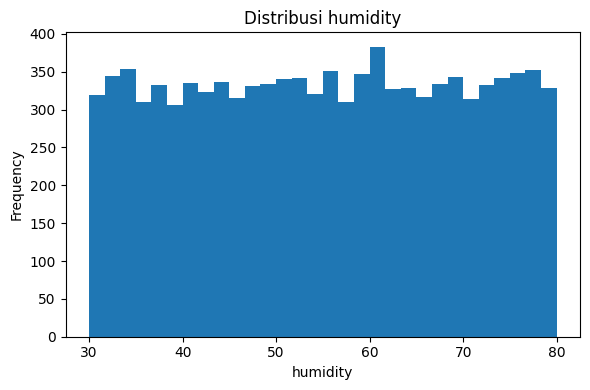

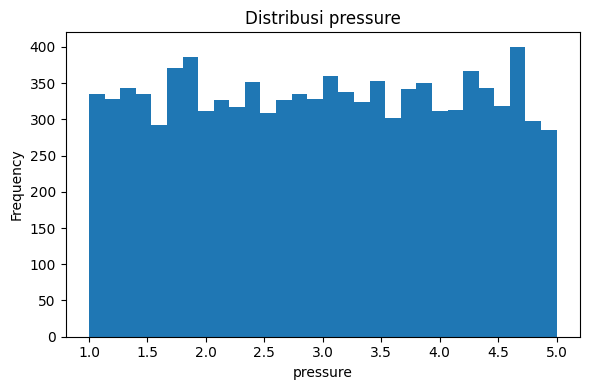

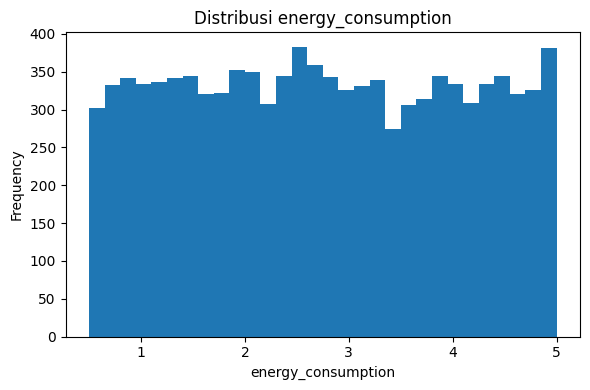

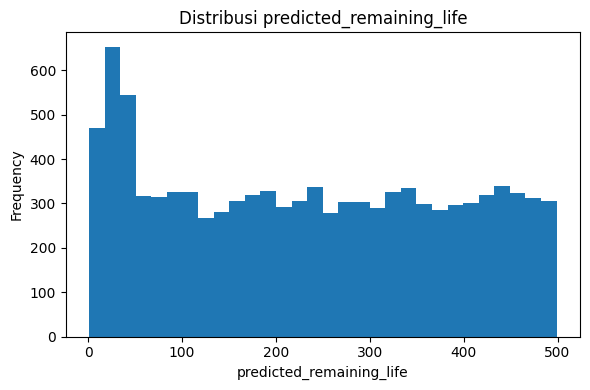

In [11]:
# Histogram fitur numerik
for col in numeric_features:
    plt.figure(figsize=(6, 4))
    plt.hist(df[col], bins=30)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

In [12]:
# Korelasi numerik dengan target
correlation_with_target = (
    df.select_dtypes(include=np.number)
      .corr()["maintenance_required"]
      .sort_values(ascending=False)
)

correlation_with_target

maintenance_required        1.000000
anomaly_flag                0.622827
downtime_risk               0.622827
machine_status              0.504001
temperature                 0.277272
vibration                   0.125674
pressure                    0.008654
machine_id                  0.007191
energy_consumption         -0.005403
humidity                   -0.008027
predicted_remaining_life   -0.334625
Name: maintenance_required, dtype: float64

<Figure size 700x400 with 0 Axes>

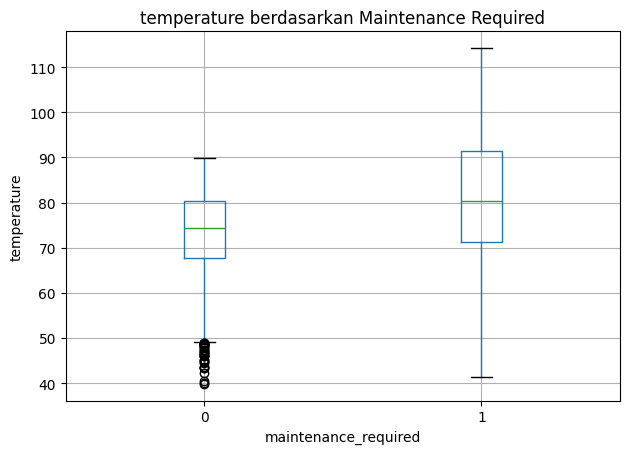

<Figure size 700x400 with 0 Axes>

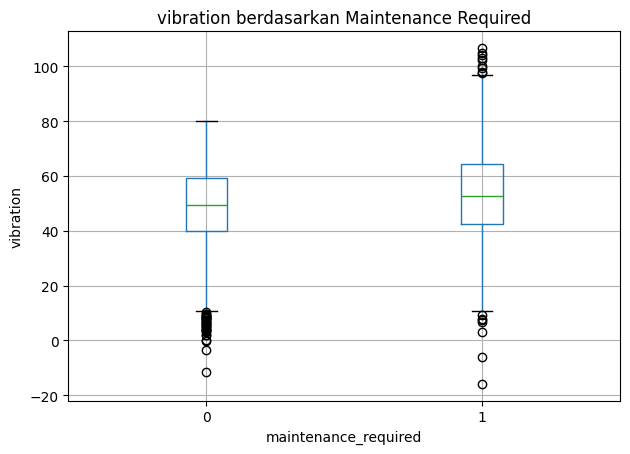

<Figure size 700x400 with 0 Axes>

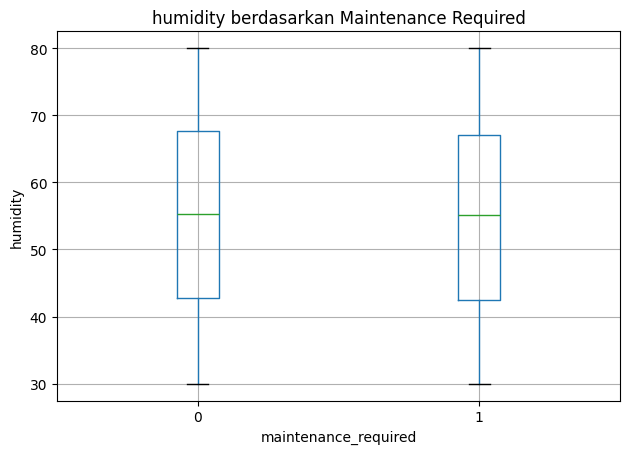

<Figure size 700x400 with 0 Axes>

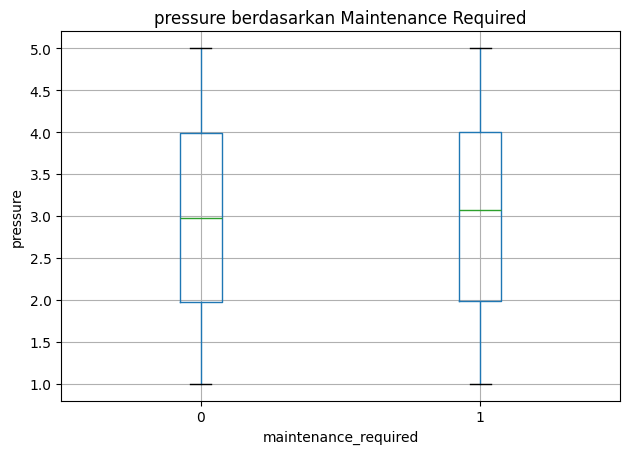

<Figure size 700x400 with 0 Axes>

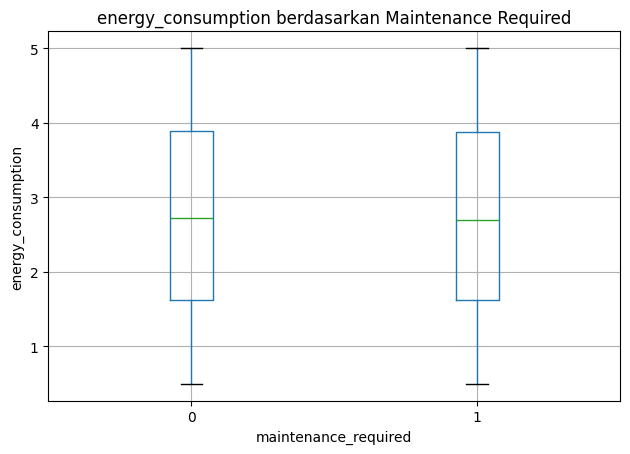

<Figure size 700x400 with 0 Axes>

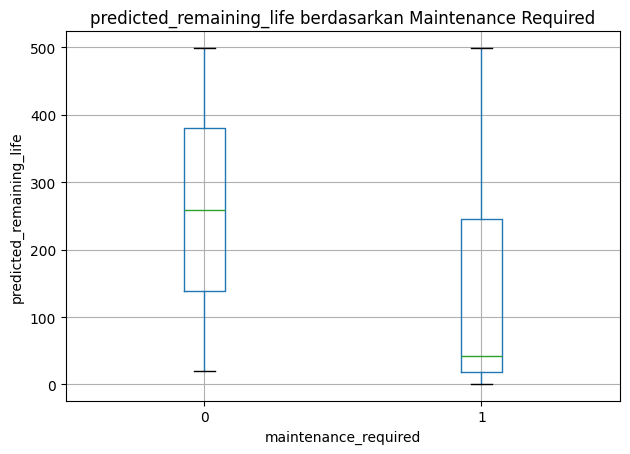

In [13]:
# Boxplot sederhana: distribusi fitur berdasarkan target
for col in numeric_features:
    plt.figure(figsize=(7, 4))
    df.boxplot(column=col, by=target)
    plt.title(f"{col} berdasarkan Maintenance Required")
    plt.suptitle("")
    plt.xlabel("maintenance_required")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## 6. Analisis Potensi Data Leakage

Beberapa kolom terlihat sangat dekat dengan target. Kita cek hubungan:

- `anomaly_flag`
- `machine_status`
- `failure_type`
- `downtime_risk`

**Catatan metodologis:** fitur yang secara langsung/nyaris langsung mengandung informasi target dapat membuat performa model terlihat sangat tinggi tetapi tidak merepresentasikan prediksi yang benar-benar berguna.

In [14]:
# anomaly_flag vs target
print("Crosstab anomaly_flag vs maintenance_required")
display(pd.crosstab(
    df["anomaly_flag"],
    df["maintenance_required"],
    normalize="index"
).round(4))

print("\nCrosstab machine_status vs maintenance_required")
display(pd.crosstab(
    df["machine_status"],
    df["maintenance_required"],
    normalize="index"
).round(4))

print("\nCrosstab failure_type vs maintenance_required")
display(pd.crosstab(
    df["failure_type"],
    df["maintenance_required"],
    normalize="index"
).round(4))

print("\nCrosstab downtime_risk vs maintenance_required")
display(pd.crosstab(
    df["downtime_risk"],
    df["maintenance_required"],
    normalize="index"
).round(4))

Crosstab anomaly_flag vs maintenance_required


maintenance_required,0,1
anomaly_flag,,
0,0.8786,0.1214
1,0.0000,1.0000



Crosstab machine_status vs maintenance_required


maintenance_required,0,1
machine_status,,
0,0.8934,0.1066
1,0.8910,0.1090
2,0.0000,1.0000



Crosstab failure_type vs maintenance_required


maintenance_required,0,1
failure_type,,
Electrical Fault,0.0000,1.0000
Normal,0.8723,0.1277
Overheating,0.0000,1.0000
Pressure Drop,0.0000,1.0000
Vibration Issue,0.0000,1.0000



Crosstab downtime_risk vs maintenance_required


maintenance_required,0,1
downtime_risk,,
0.00,0.8786,0.1214
0.99,0.0000,1.0000
1.00,0.0000,1.0000


In [15]:
# Pemeriksaan aturan deterministik yang mencurigakan

checks = {
    "anomaly_flag = 1 -> maintenance = 1":
        (df.loc[df["anomaly_flag"] == 1, target] == 1).mean(),
    "machine_status = 2 -> maintenance = 1":
        (df.loc[df["machine_status"] == 2, target] == 1).mean(),
    "failure_type != Normal -> maintenance = 1":
        (df.loc[df["failure_type"] != "Normal", target] == 1).mean(),
}

pd.Series(checks, name="proporsi_maintenance_1")

anomaly_flag = 1 -> maintenance = 1          1.0
machine_status = 2 -> maintenance = 1        1.0
failure_type != Normal -> maintenance = 1    1.0
Name: proporsi_maintenance_1, dtype: float64

### Keputusan leakage

Untuk **baseline supervised model**, kita tidak menggunakan:

- `maintenance_required` — target
- `anomaly_flag` — sangat dekat dengan target
- `downtime_risk` — sangat dekat dengan target
- `failure_type` — kategori non-Normal selalu terkait dengan maintenance
- `machine_status` — nilai tertentu secara deterministik terkait dengan maintenance
- `machine_id` — identifier mesin, bukan pengukuran kondisi
- `timestamp` — tidak digunakan mentah sebagai fitur

Kita menggunakan fitur sensor/operasional berikut:

- `temperature`
- `vibration`
- `humidity`
- `pressure`
- `energy_consumption`
- `predicted_remaining_life`

> `predicted_remaining_life` perlu dikonfirmasi asal-usul pembentukannya jika sistem ini akan dipakai production, karena kolom tersebut sendiri merupakan hasil prediksi.

In [16]:
FEATURES = [
    "temperature",
    "vibration",
    "humidity",
    "pressure",
    "energy_consumption",
    "predicted_remaining_life"
]

TARGET = "maintenance_required"

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("Features:", FEATURES)
print("Target:", TARGET)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['temperature', 'vibration', 'humidity', 'pressure', 'energy_consumption', 'predicted_remaining_life']
Target: maintenance_required
X shape: (10000, 6)
y shape: (10000,)


## 7. Train-Test Split

Kita menggunakan 80% data untuk training dan 20% untuk testing.

`stratify=y` digunakan agar proporsi kelas target relatif terjaga pada train dan test.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nDistribusi target train:")
display(y_train.value_counts(normalize=True).sort_index().rename("proportion"))

print("\nDistribusi target test:")
display(y_test.value_counts(normalize=True).sort_index().rename("proportion"))

X_train: (8000, 6)
X_test : (2000, 6)
y_train: (8000,)
y_test : (2000,)

Distribusi target train:


maintenance_required
0    0.801625
1    0.198375
Name: proportion, dtype: float64


Distribusi target test:


maintenance_required
0    0.8015
1    0.1985
Name: proportion, dtype: float64

## 8. Baseline Model

Sebagai pembanding, kita membuat model paling sederhana: selalu memprediksi kelas mayoritas.

In [18]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

baseline_accuracy = accuracy_score(y_test, baseline_pred)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")

Baseline Accuracy: 0.8015


## 9. Random Forest Classifier

Random Forest dipilih sebagai model supervised utama sesuai pembagian tugas ML Engineer 1.

Model menggunakan fitur numerik sehingga tidak memerlukan standard scaling.

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest berhasil dilatih.")

Random Forest berhasil dilatih.


In [20]:
# Prediksi kelas dan probabilitas
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print("5 prediksi pertama:", y_pred[:5])
print("5 probabilitas pertama:", np.round(y_proba[:5], 4))

5 prediksi pertama: [0 0 0 0 0]
5 probabilitas pertama: [0.1167 0.0767 0.0933 0.0367 0.05  ]


## 10. Evaluasi Model

Karena target tidak seimbang, kita melihat:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- PR-AUC

Untuk kasus maintenance, **recall kelas 1** penting karena false negative berarti kasus yang membutuhkan maintenance tetapi diprediksi tidak membutuhkan maintenance.

In [21]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "PR-AUC": average_precision_score(y_test, y_proba)
}

metrics_df = pd.DataFrame({
    "Metric": list(metrics.keys()),
    "Value": list(metrics.values())
})

metrics_df["Value"] = metrics_df["Value"].round(4)
metrics_df

,Metric,Value
0,Accuracy,0.9090
1,Precision,0.9821
2,Recall,0.5516
3,F1,0.7065
4,ROC-AUC,0.7811
5,PR-AUC,0.7055


In [22]:
print("Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Maintenance", "Maintenance Required"],
    digits=4,
    zero_division=0
))

Classification Report:
                      precision    recall  f1-score   support

      No Maintenance     0.8998    0.9975    0.9462      1603
Maintenance Required     0.9821    0.5516    0.7065       397

            accuracy                         0.9090      2000
           macro avg     0.9409    0.7746    0.8263      2000
        weighted avg     0.9162    0.9090    0.8986      2000



## 11. Confusion Matrix

Confusion matrix membantu melihat:

- True Negative (TN)
- False Positive (FP)
- False Negative (FN)
- True Positive (TP)

Confusion Matrix:
[[1599    4]
 [ 178  219]]


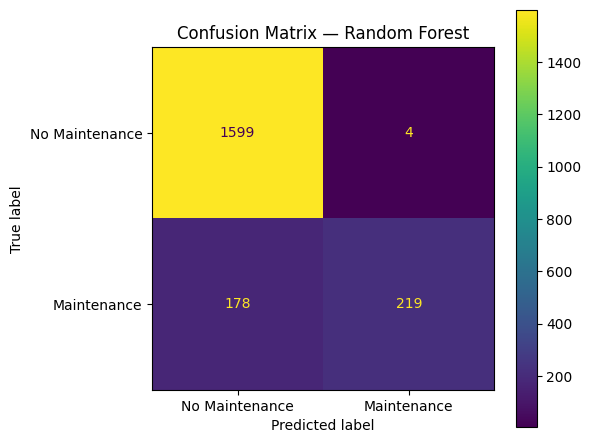

In [23]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Maintenance", "Maintenance"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax)
ax.set_title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

## 12. Feature Importance

Feature importance digunakan untuk melihat fitur mana yang paling banyak digunakan oleh Random Forest dalam membuat keputusan.

**Interpretasi:** importance bukan bukti hubungan sebab-akibat.

In [24]:
feature_importance = pd.DataFrame({
    "feature": FEATURES,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
5,predicted_remaining_life,0.308532
0,temperature,0.220500
1,vibration,0.155180
2,humidity,0.109735
3,pressure,0.103353
4,energy_consumption,0.102701


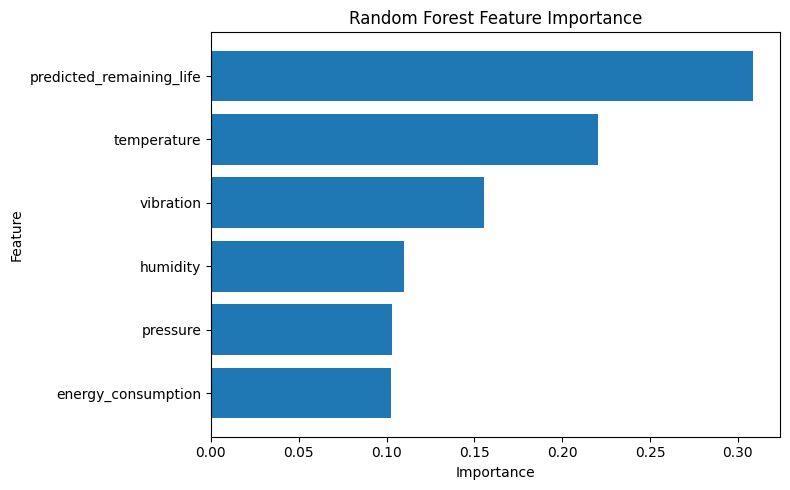

In [25]:
plt.figure(figsize=(8, 5))
plt.barh(
    feature_importance["feature"][::-1],
    feature_importance["importance"][::-1]
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 13. Contoh Prediksi Satu Mesin

Bagian ini menunjukkan format input yang nantinya dapat digunakan backend Flask.

In [26]:
sample_input = pd.DataFrame([{
    "temperature": 75.2,
    "vibration": 4.8,
    "humidity": 62.1,
    "pressure": 101.3,
    "energy_consumption": 68.5,
    "predicted_remaining_life": 120
}])

sample_prediction = rf_model.predict(sample_input)[0]
sample_probability = rf_model.predict_proba(sample_input)[0, 1]

result = {
    "maintenance_required": int(sample_prediction),
    "probability": float(sample_probability)
}

result

{'maintenance_required': 0, 'probability': 0.13333333333333333}

## 14. Menyimpan Model

Model disimpan dalam format `.pkl` menggunakan `joblib`.

Backend dapat memuat file ini tanpa melakukan training ulang.

In [27]:
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODEL_DIR, "maintenance_classifier.pkl")

joblib.dump(rf_model, MODEL_PATH)

print("Model berhasil disimpan di:", MODEL_PATH)

Model berhasil disimpan di: models/maintenance_classifier.pkl


In [28]:
# Verifikasi model dapat dimuat kembali
loaded_model = joblib.load(MODEL_PATH)

loaded_prediction = loaded_model.predict(sample_input)[0]

print("Prediction dari model yang sudah di-load:", int(loaded_prediction))

Prediction dari model yang sudah di-load: 0


# 15. Ringkasan untuk Laporan

### Problem
Memprediksi apakah mesin membutuhkan maintenance (`maintenance_required`).

### Target
Binary classification:
- 0 = tidak membutuhkan maintenance
- 1 = membutuhkan maintenance

### Model
Random Forest Classifier.

### Fitur
- temperature
- vibration
- humidity
- pressure
- energy_consumption
- predicted_remaining_life

### Leakage analysis
`anomaly_flag`, `downtime_risk`, `machine_status`, dan `failure_type` menunjukkan hubungan yang sangat kuat/deterministik dengan target sehingga dikeluarkan dari baseline untuk mengurangi risiko target leakage.

### Evaluasi
Gunakan Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, dan Confusion Matrix.

### Output model
- `maintenance_required`
- probabilitas kelas maintenance

### Artefak
`models/maintenance_classifier.pkl`